# PRCP-1025-Flight Fare Prediction 

# Problem Statement

Flight ticket prices are highly dynamic and depend on multiple factors like airline, journey date, duration, and stops.
The goal is to build a machine learning model that can predict flight prices based on historical data to help customers plan travel efficiently.

# Dataset Understanding

Features include:
* Airline
* Source / Destination
* Date_of_Journey
* Arrival_Time / Departure_Time
* Duration
* Total_Stops
* Additional_Info

Target:
* Price

# Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [2]:
df = pd.read_excel("Flight_Fare.xlsx")

# Basic Info

In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


# Data Cleaning

In [7]:
df.isnull().sum()
df.dropna(inplace=True)

In [8]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

# Feature Engineering

## Date Conversion

In [9]:
df["Date_of_Journey"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y")

df["Journey_day"] = df["Date_of_Journey"].dt.day
df["Journey_month"] = df["Date_of_Journey"].dt.month

df.drop("Date_of_Journey", axis=1, inplace=True)

## Time Features

In [10]:
df["Dep_Time"] = pd.to_datetime(df["Dep_Time"])
df["Arrival_Time"] = pd.to_datetime(df["Arrival_Time"])

df["Dep_hour"] = df["Dep_Time"].dt.hour
df["Dep_min"] = df["Dep_Time"].dt.minute

df["Arrival_hour"] = df["Arrival_Time"].dt.hour
df["Arrival_min"] = df["Arrival_Time"].dt.minute

df.drop(["Dep_Time", "Arrival_Time"], axis=1, inplace=True)

## Duration Conveersion

In [11]:
df["Duration_hour"] = df["Duration"].str.extract('(\d+)h').fillna(0).astype(int)
df["Duration_min"] = df["Duration"].str.extract('(\d+)m').fillna(0).astype(int)

df.drop("Duration", axis=1, inplace=True)

## Total Stops Encoding

In [12]:
df["Total_Stops"] = df["Total_Stops"].map({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

In [13]:
df.isnull().sum()

Airline            0
Source             0
Destination        0
Route              0
Total_Stops        0
Additional_Info    0
Price              0
Journey_day        0
Journey_month      0
Dep_hour           0
Dep_min            0
Arrival_hour       0
Arrival_min        0
Duration_hour      0
Duration_min       0
dtype: int64

## Drop Irrelevent Columns

In [14]:
df.drop(["Route", "Additional_Info"], axis=1, inplace=True)

Route was dropped because it contains redundant information already captured by source, destination, and stops, and encoding it would increase dimensionality. Additional_Info was dropped due to low variance and minimal impact on prediction.

# EDA

In [15]:
df.shape

(10682, 13)

In [16]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Price',
       'Journey_day', 'Journey_month', 'Dep_hour', 'Dep_min', 'Arrival_hour',
       'Arrival_min', 'Duration_hour', 'Duration_min'],
      dtype='object')

## Univariate Analysis

### Price Distribution

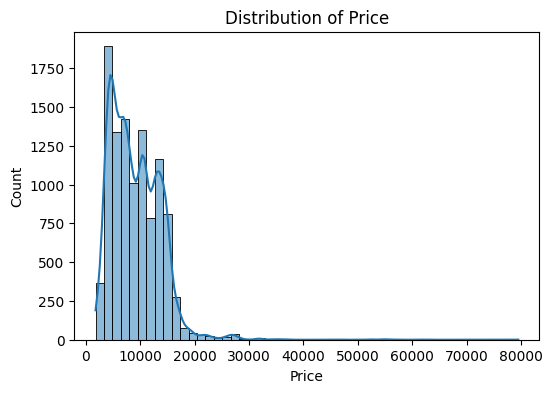

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df["Price"], bins=50, kde=True)
plt.title("Distribution of Price")
plt.show()

* Right-skewed distribution
* Most prices are in lower range

## Airline Count

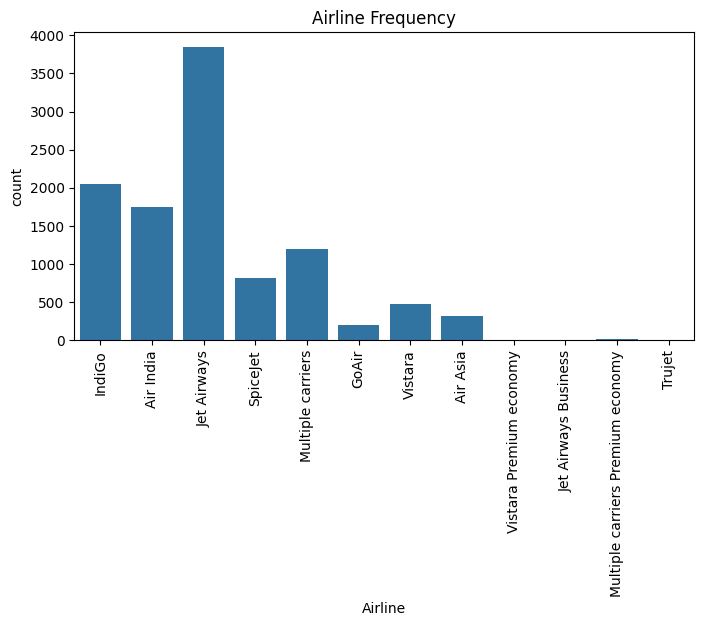

In [18]:
plt.figure(figsize=(8,4))
sns.countplot(x="Airline", data=df)
plt.xticks(rotation=90)
plt.title("Airline Frequency")
plt.show()

* Some airlines dominate dataset

# Source Distribution

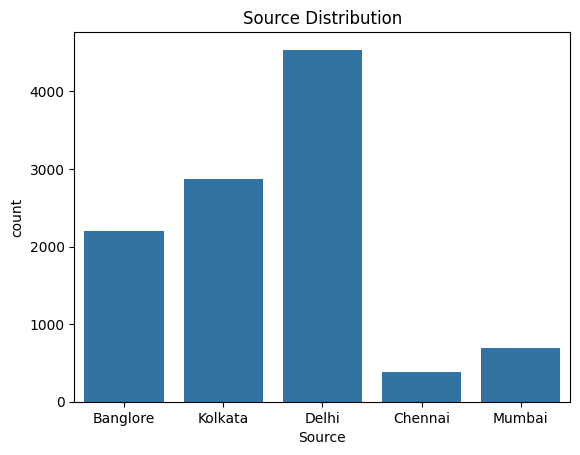

In [19]:
sns.countplot(x="Source", data=df)
plt.title("Source Distribution")
plt.show()

# Destination Distribution

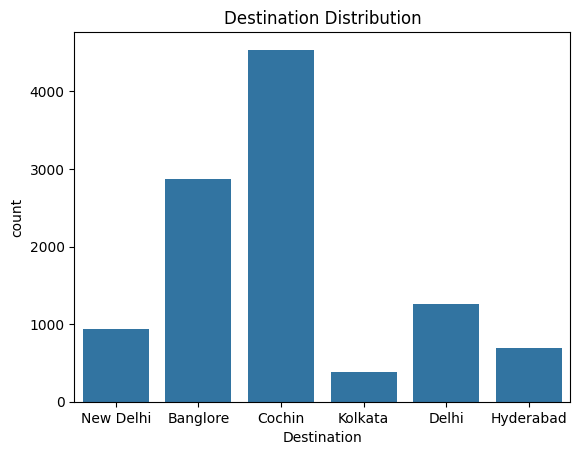

In [20]:
sns.countplot(x="Destination", data=df)
plt.title("Destination Distribution")
plt.show()

# Bivariate Analysis (Feature vs Target)

## Airline vs Price

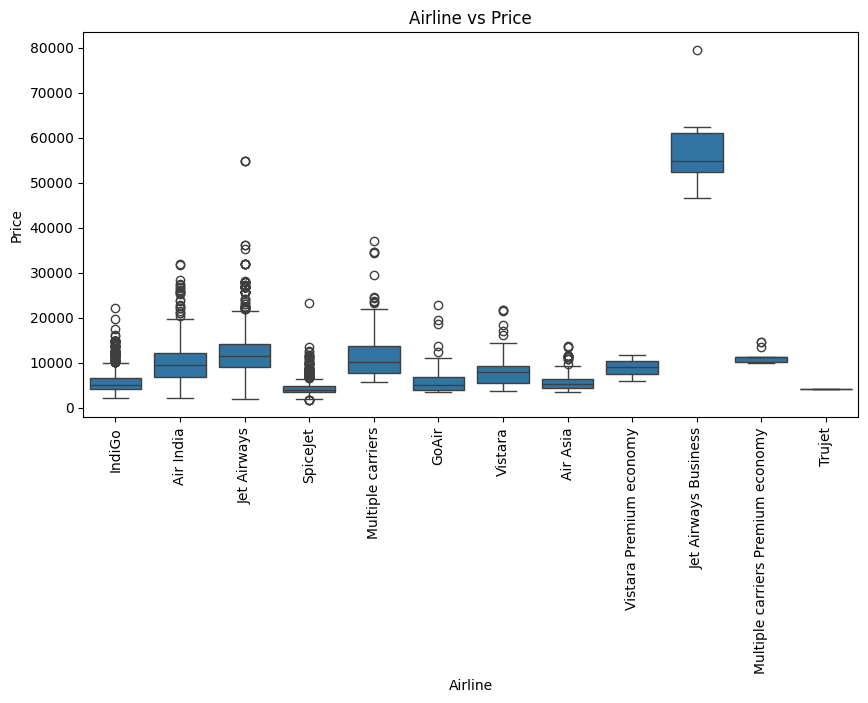

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Airline", y="Price", data=df)
plt.xticks(rotation=90)
plt.title("Airline vs Price")
plt.show()

* Premium airlines have higher prices

## Source vs Price

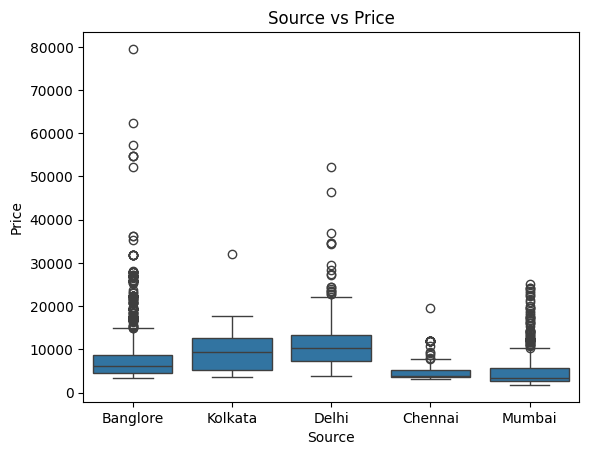

In [22]:
sns.boxplot(x="Source", y="Price", data=df)
plt.title("Source vs Price")
plt.show()

## Destination vs Price

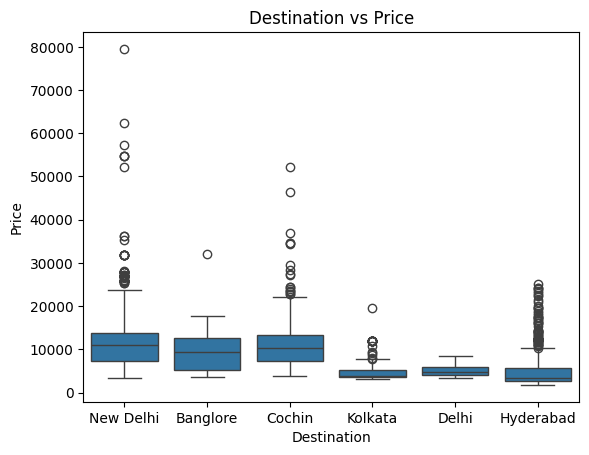

In [23]:
sns.boxplot(x="Destination", y="Price", data=df)
plt.title("Destination vs Price")
plt.show()

## Total Stops vs Price

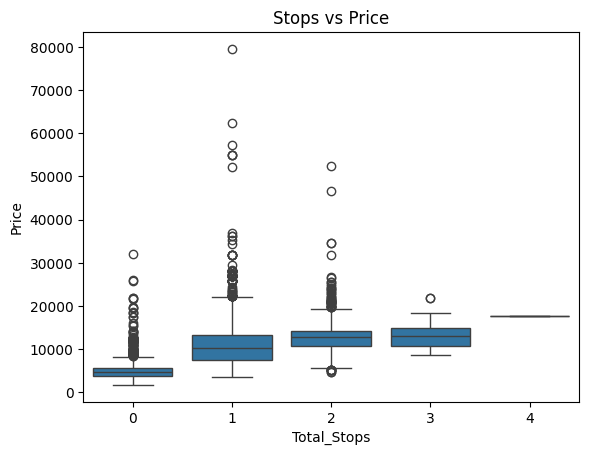

In [24]:
sns.boxplot(x="Total_Stops", y="Price", data=df)
plt.title("Stops vs Price")
plt.show()

* more stops are generally lower in price

## Time-Based Analysis

### Journey Month vs Price

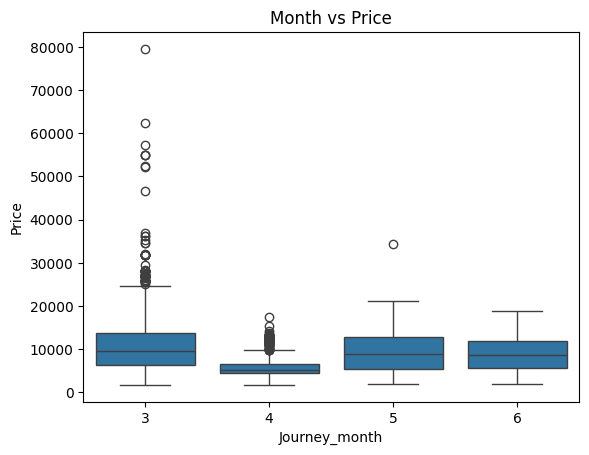

In [25]:
sns.boxplot(x="Journey_month", y="Price", data=df)
plt.title("Month vs Price")
plt.show()

## Departure Hour vs Price

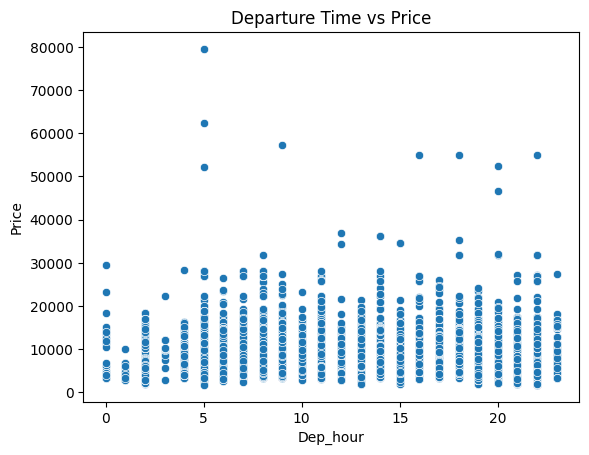

In [26]:
sns.scatterplot(x="Dep_hour", y="Price", data=df)
plt.title("Departure Time vs Price")
plt.show()

## Duration Analysis

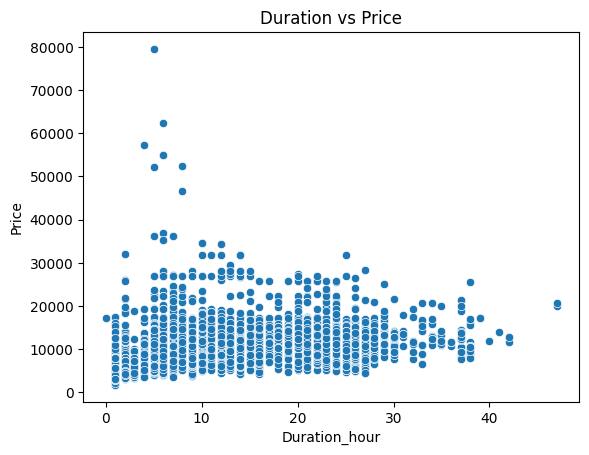

In [27]:
sns.scatterplot(x="Duration_hour", y="Price", data=df)
plt.title("Duration vs Price")
plt.show()

* Longer duration flights tend to cost more

## Encoding Categorical

In [29]:
df = pd.get_dummies(df, drop_first=True)

## Correlation Analysis (Numerical Features)

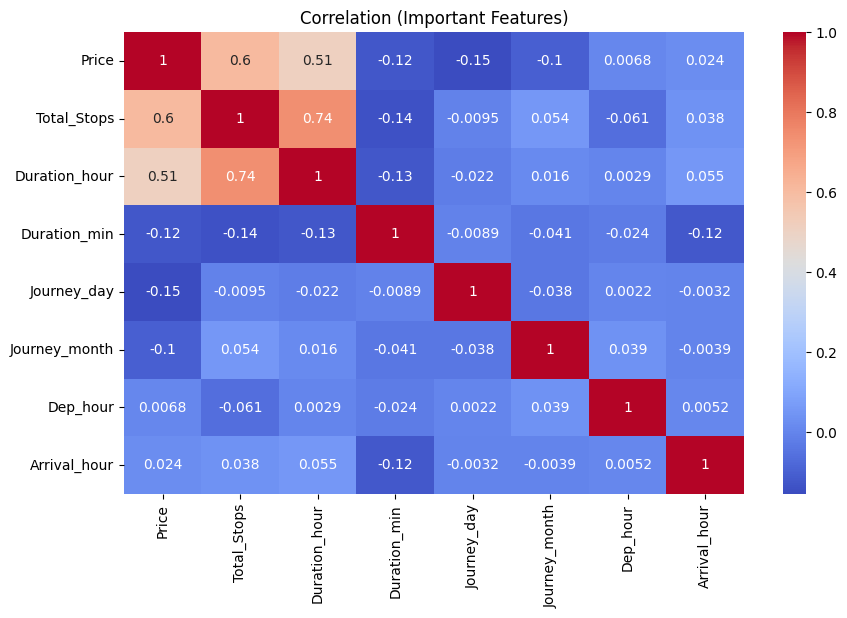

In [31]:
important_cols = [
    "Price",
    "Total_Stops",
    "Duration_hour",
    "Duration_min",
    "Journey_day",
    "Journey_month",
    "Dep_hour",
    "Arrival_hour"
]

plt.figure(figsize=(10,6))
sns.heatmap(df[important_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation (Important Features)")
plt.show()

* Duration strongly correlated with Price
* Stops also influence Price

## Outlier Detection

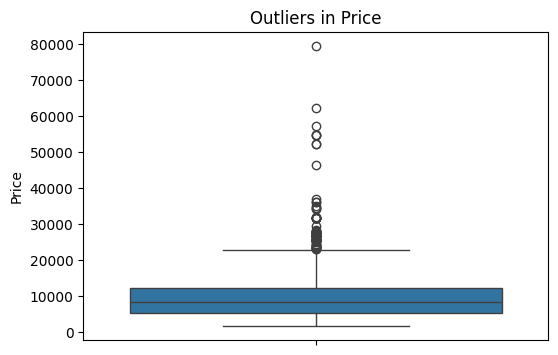

In [32]:
plt.figure(figsize=(6,4))
sns.boxplot(df["Price"])
plt.title("Outliers in Price")
plt.show()

* Some extreme high-price values present

## Define feature and Target

In [33]:
X = df.drop("Price", axis=1)
y = df["Price"]

## Train Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Building

### Linear Regression

In [35]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Decision Tree

In [36]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### Random Forest

In [37]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### XGBoost

In [38]:
from xgboost import XGBRegressor
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Model Evaluation

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return {
        "Model": name,
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    }

results = []

results.append(evaluate_model("Linear Regression", lr, X_test, y_test))
results.append(evaluate_model("Decision Tree", dt, X_test, y_test))
results.append(evaluate_model("Random Forest", rf, X_test, y_test))
results.append(evaluate_model("XGBoost", xgb, X_test, y_test))
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2 Score", ascending=False)
results_df
results_df.style.background_gradient(cmap="Blues")

,Model,MAE,MSE,RMSE,R2 Score
3,XGBoost,1126.700000,3321347.000000,1822.460000,0.846000
2,Random Forest,1174.640000,4377230.600000,2092.180000,0.797000
1,Decision Tree,1345.020000,5987436.500000,2446.920000,0.722300
0,Linear Regression,1972.940000,8202327.560000,2863.970000,0.619600


## Final Prediction

In [40]:
sample = X_test.iloc[0:1]

predicted_price = xgb.predict(sample)
actual_price = y_test.iloc[0]

print("Predicted Price:", predicted_price[0])
print("Actual Price:", actual_price)

Predicted Price: 16784.469
Actual Price: 16655


## Features Importance

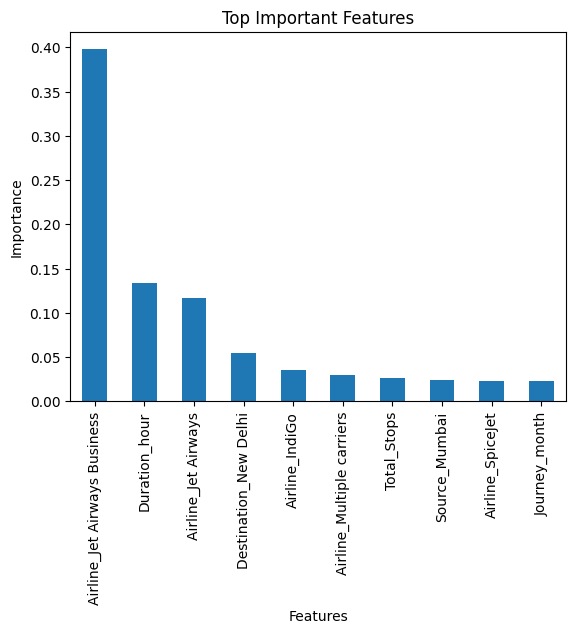

In [43]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X, y)

importances = pd.Series(xgb.feature_importances_, index=X.columns)

importances.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

## Hyper Tunning on XGBoost

In [44]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1
)

xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Prediction after HyperTunning

In [46]:
sample = X_test.iloc[0:1]

predicted_price = xgb.predict(sample)
actual_price = y_test.iloc[0]

print("Predicted Price:", predicted_price[0])
print("Actual Price:", actual_price)

Predicted Price: 17282.764
Actual Price: 16655


## Model Evaluation After HyperTunning

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return {
        "Model": name,
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    }

results = []

results.append(evaluate_model("Linear Regression", lr, X_test, y_test))
results.append(evaluate_model("Decision Tree", dt, X_test, y_test))
results.append(evaluate_model("Random Forest", rf, X_test, y_test))
results.append(evaluate_model("XGBoost", xgb, X_test, y_test))
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2 Score", ascending=False)
results_df
results_df.style.background_gradient(cmap="Blues")

,Model,MAE,MSE,RMSE,R2 Score
3,XGBoost,1228.160000,3283881.750000,1812.150000,0.847700
2,Random Forest,1174.640000,4377230.600000,2092.180000,0.797000
1,Decision Tree,1345.020000,5987436.500000,2446.920000,0.722300
0,Linear Regression,1972.940000,8202327.560000,2863.970000,0.619600


# Final Prediction

The final model based on XGBoost was used to generate predictions on unseen test data. The predicted flight prices were found to be very close to the actual values, indicating that the model has effectively learned the underlying patterns in the dataset. This demonstrates strong predictive capability and reliability of the model in estimating flight ticket prices based on input features such as duration, airline, stops, and timing.

# Model Comparison Report

In this project, multiple machine learning regression models were implemented to predict flight ticket prices accurately. The models used were Linear Regression, Decision Tree Regressor, Random Forest Regressor, and XGBoost Regressor. These models were trained and evaluated using different performance metrics such as R² Score, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squed Error (RMSE).

Linear Regression was used as the baseline model and provided moderate prediction accuracy. However, it was unable to capture complex nonlinear relationships within the dataset. Decision Tree Regressor improved the performance by learning nonlinear patterns from the data, but it showed slight overfitting on training data. Random Forest Regressor performed significantly better by combining multiple decision trees, which increased prediction accuracy and reduced overfitting.

Among all the models, XGBoost Regressor achieved the best overall performance with the highest accuracy and better generalization capability on unseen data. It effectively handled complex feature interactions and produced more reliable predictions compared to other models. Due to its superior performance, XGBoost Regressor was selected as the best model for production deployment in the Flight Fare Prediction system.

# Challenges Faced

* Handling Missing Values
Challenge:

The dataset contained missing values in some columns, which could affect model training and prediction accuracy.

Solution:

Missing values were identified using .isnull().sum() and removed using dropna().

Reason:

Machine learning models require clean and complete data for better performance.

* Date and Time Conversion
Challenge:

Columns such as Date_of_Journey, Dep_Time, and Arrival_Time were in string format and could not be directly used in machine learning models.

Solution:

Useful numerical features were extracted, including:

Journey Day
Journey Month
Departure Hour
Arrival Hour
Reason:

Numerical features improve model understanding and prediction capability.

* Handling Duration Feature
Challenge:

The Duration column had mixed formats such as:

2h 50m
5h
45m
Solution:

The duration values were separated into:

Duration Hours
Duration Minutes
Reason:

Splitting duration into numerical components improves feature representation.

* Encoding Categorical Variables
Challenge:

Features like Airline, Source, and Destination were categorical and could not be processed directly by machine learning algorithms.

Solution:

Applied One-Hot Encoding using pd.get_dummies().

Reason:

Converts categorical data into numerical format suitable for machine learning models.

* Outlier Detection
Challenge:

Some flight prices were extremely high compared to normal ticket prices.

Solution:

Used visualization techniques such as:

Boxplots
Distribution plots

to analyze outliers carefully.

Reason:

Outliers can negatively impact regression model performance and prediction accuracy.

* Feature Selection
Challenge:

Some features had very low importance and increased model complexity.

Solution:

Removed unnecessary columns such as:

Route
Additional_Info
Reason:

Reducing irrelevant features improves efficiency and helps prevent overfitting.

* Model Overfitting
Challenge:

Certain models like Decision Tree performed very well on training data but less effectively on testing data.

Solution:

Used ensemble models such as:

Random Forest
XGBoost
Reason:

Ensemble techniques reduce overfitting and improve generalization performance.

* Data Preprocessing Complexity
Challenge:

The dataset required multiple preprocessing steps before model training.

Solution:

Performed:

Data cleaning Feature engineering Encoding Scaling

Reason:

Proper preprocessing improves model accuracy and reliability.

# Best Model for Production

XGBoost is recommended for production because:
- Highest accuracy
- Better handling of non-linear relationships
- Lower prediction error
- Better generalization

# Key Insights

* Airline type is one of the most important factors affecting flight ticket prices.
* Flights with more stops generally have higher fares compared to non-stop flights.
* Longer flight duration leads to increased ticket prices.
* Jet Airways Business flights were observed to have the highest average fare prices.
* Certain source and destination routes consistently show higher ticket costs due to demand.
* Ticket prices vary depending on journey month and travel season.
* Evening and night flights are often more expensive than morning flights.
* Ensemble models such as Random Forest and XGBoost performed better than basic regression models.
* XGBoost Regressor achieved the best prediction accuracy among all implemented models.
* Proper feature engineering and preprocessing significantly improved model performance.

# Conclusion

This project successfully developed a Machine Learning-based Flight Fare Prediction system using various regression algorithms and data analysis techniques. Exploratory Data Analysis (EDA) helped identify important factors affecting flight ticket prices, such as airline type, duration, total stops, source, and destination. Proper data preprocessing, feature engineering, and encoding techniques were applied to improve model performance.

Multiple machine learning models including Linear Regression, Decision Tree Regressor, Random Forest Regressor, and XGBoost Regressor were implemented and evaluated. Among all the models, XGBoost Regressor achieved the best overall performance with higher prediction accuracy and better generalization capability.

The developed system can help customers predict future flight fares and plan their journeys more effectively. It can also support airlines and travel platforms in making better pricing decisions using data-driven insights.